# 🌸 Task 1 — Iris Flower Classification
**CodeAlpha Data Science Internship**  
Intern: Asiedu Seth Osei | ID: CA/DF1/63603

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


## 2. Load & Explore the Dataset

In [5]:
df = pd.read_csv('./data/Iris.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [6]:
# Clean up: 
df.drop('Id', axis=1, inplace=True)
df['Species'] = df['Species'].str.replace('Iris-', '', regex=False)
print("Class distribution:")
print(df['Species'].value_counts())
df.describe().round(2)

Class distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [7]:
print("Missing values:")
df.isnull().sum()

Missing values:


SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## 3. Exploratory Data Analysis

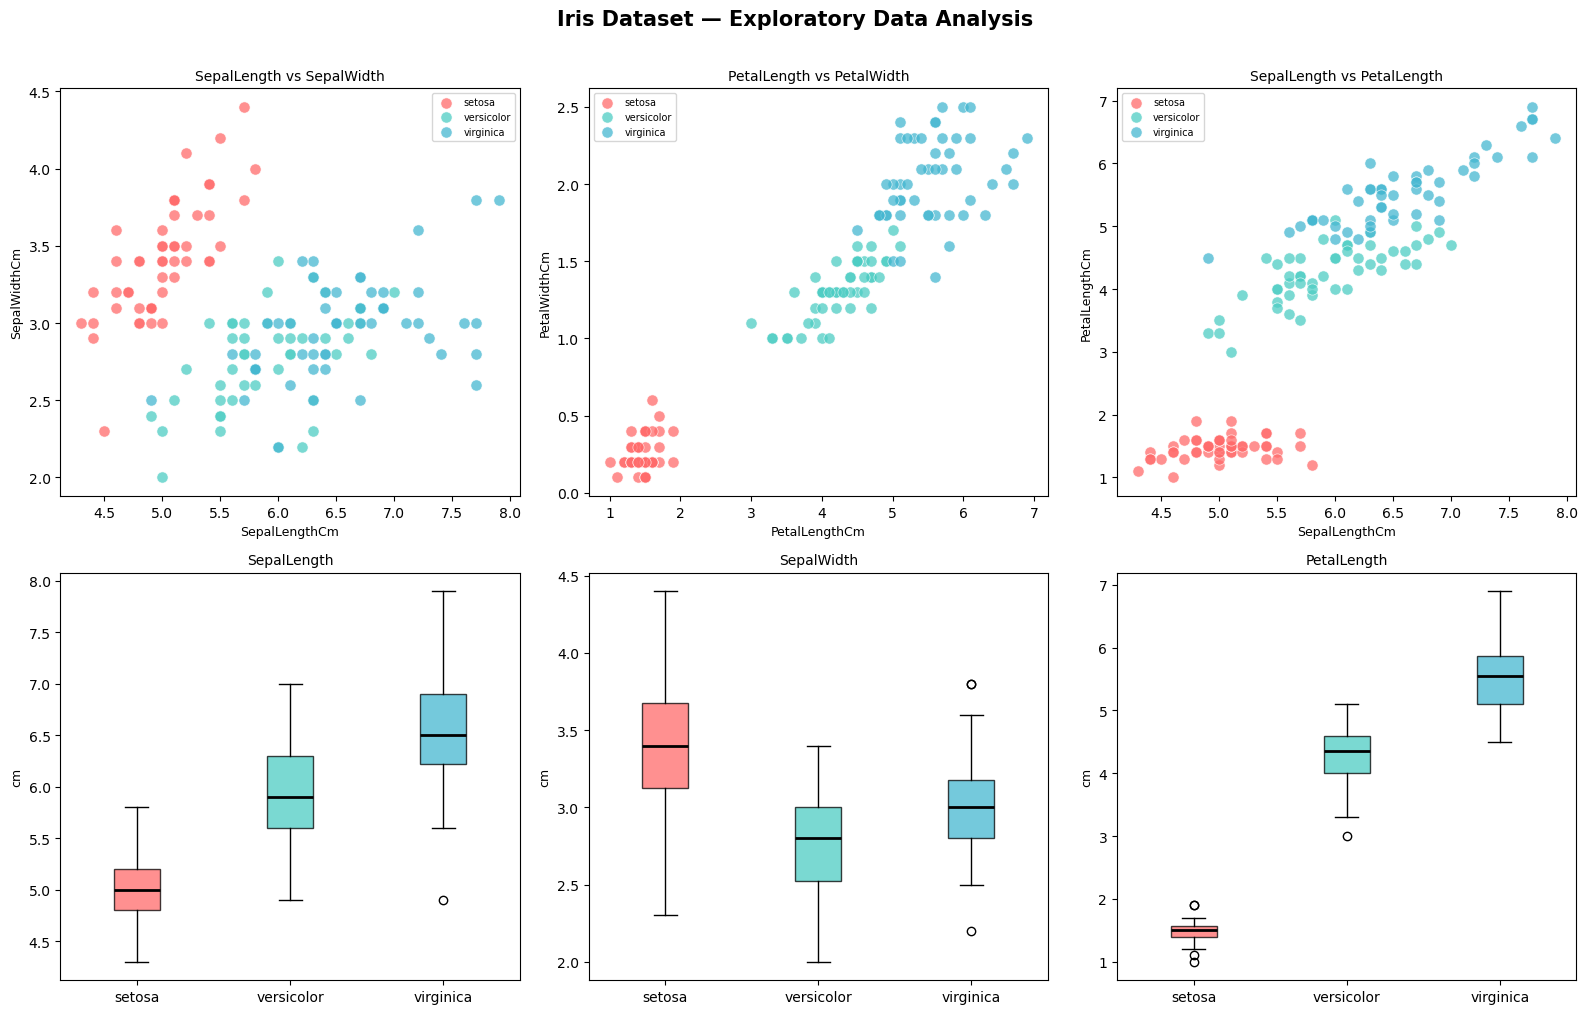

EDA plot saved


In [8]:
palette = {'setosa': '#FF6B6B', 'versicolor': '#4ECDC4', 'virginica': '#45B7D1'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Iris Dataset — Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)

# Scatter plots
pairs = [
    ('SepalLengthCm','SepalWidthCm'),
    ('PetalLengthCm','PetalWidthCm'),
    ('SepalLengthCm','PetalLengthCm'),
]
for ax, (fx, fy) in zip(axes[0], pairs):
    for sp, color in palette.items():
        sub = df[df['Species']==sp]
        ax.scatter(sub[fx], sub[fy], label=sp, alpha=0.75,
                   color=color, edgecolors='white', s=65, linewidth=0.5)
    ax.set_xlabel(fx, fontsize=9); ax.set_ylabel(fy, fontsize=9)
    ax.set_title(f'{fx.replace("Cm","")} vs {fy.replace("Cm","")}', fontsize=10)
    ax.legend(fontsize=7)

# Box plots
features = ['SepalLengthCm','SepalWidthCm','PetalLengthCm']
for ax, feat in zip(axes[1], features):
    data_by_class = [df[df['Species']==sp][feat].values for sp in palette]
    bp = ax.boxplot(data_by_class, patch_artist=True, labels=list(palette.keys()),
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], palette.values()):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(feat.replace('Cm',''), fontsize=10)
    ax.set_ylabel('cm', fontsize=9)

plt.tight_layout()
plt.savefig('./outputs/eda_iris.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved")

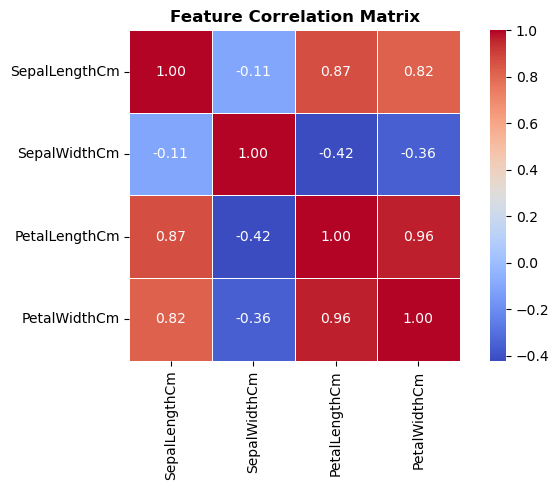

In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df.drop('Species', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/correlation_iris.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing & Train/Test Split

In [10]:
le = LabelEncoder()
X = df.drop('Species', axis=1).values
y = le.fit_transform(df['Species'])
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Classes     : {class_names}")
print(f"Train size  : {len(X_train)}")
print(f"Test  size  : {len(X_test)}")

Classes     : ['setosa' 'versicolor' 'virginica']
Train size  : 120
Test  size  : 30


## 5. Train & Compare Models

In [11]:
models = {
    'Logistic Regression':  LogisticRegression(max_iter=200, random_state=42),
    'K-Nearest Neighbors':  KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', C=1.0, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(max_depth=4, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<26} {'CV Mean':>8} {'CV Std':>8} {'Test Acc':>9}")
print('─' * 58)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')
    test_acc  = accuracy_score(y_test, model.predict(X_test_s))
    results[name] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
                     'test_acc': test_acc, 'model': model}
    print(f"{name:<26} {cv_scores.mean():>8.4f} {cv_scores.std():>8.4f} {test_acc:>9.4f}")

best_name  = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']
print(f'\n🏆 Best model: {best_name}  ({results[best_name]["test_acc"]:.4f})')

Model                       CV Mean   CV Std  Test Acc
──────────────────────────────────────────────────────────
Logistic Regression          0.9583   0.0264    0.9333
K-Nearest Neighbors          0.9583   0.0264    0.9333
Support Vector Machine       0.9667   0.0167    0.9667
Random Forest                0.9500   0.0312    0.9000
Decision Tree                0.9417   0.0204    0.9000

🏆 Best model: Support Vector Machine  (0.9667)


## 6. Best Model — Detailed Evaluation

In [12]:
y_pred = best_model.predict(X_test_s)
print(f"Classification Report — {best_name}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report — Support Vector Machine

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



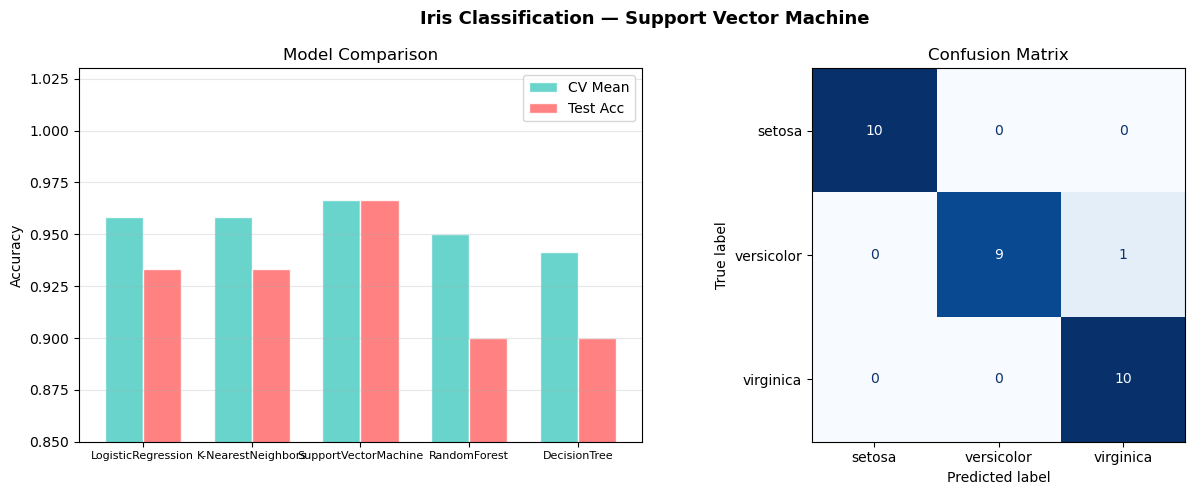

✅ Model results plot saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Iris Classification — {best_name}', fontsize=13, fontweight='bold')

# Model comparison bar chart
names  = list(results.keys())
means  = [results[n]['cv_mean'] for n in names]
test_a = [results[n]['test_acc'] for n in names]
x = np.arange(len(names)); w = 0.35

axes[0].bar(x-w/2, means, w, label='CV Mean', color='#4ECDC4', alpha=0.85, edgecolor='white')
axes[0].bar(x+w/2, test_a, w, label='Test Acc', color='#FF6B6B', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(' ','') for n in names], fontsize=8)
axes[0].set_ylim(0.85, 1.03); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Comparison'); axes[0].legend(); axes[0].yaxis.grid(True, alpha=0.3)

# Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix')

plt.tight_layout()
plt.savefig('./outputs/model_results_iris.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model results plot saved")

## 7. Feature Importance (Random Forest)

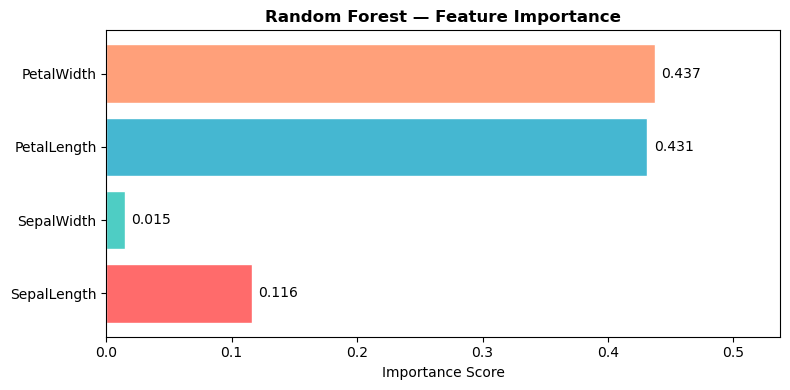

In [15]:
rf = results['Random Forest']['model']
feat_names = ['SepalLength','SepalWidth','PetalLength','PetalWidth']
importances = rf.feature_importances_

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A']
bars = ax.barh(feat_names, importances, color=colors, edgecolor='white')
for bar, imp in zip(bars, importances):
    ax.text(imp+0.005, bar.get_y()+bar.get_height()/2, f'{imp:.3f}', va='center', fontsize=10)
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest — Feature Importance', fontweight='bold')
ax.set_xlim(0, max(importances)+0.1)
plt.tight_layout()
plt.savefig('./outputs/feature_importance_iris.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Predict a New Sample

In [16]:
import numpy as np
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
sample_s = scaler.transform(sample)
pred = best_model.predict(sample_s)
print(f"Input  : SepalL=5.1, SepalW=3.5, PetalL=1.4, PetalW=0.2")
print(f"Predicted species: ➜  {class_names[pred[0]].upper()}")

Input  : SepalL=5.1, SepalW=3.5, PetalL=1.4, PetalW=0.2
Predicted species: ➜  SETOSA


---
## ✅ Task 1 Complete
**Best Model:** Support Vector Machine (RBF)  
**Test Accuracy:** 96.67%  
**GitHub:** `CodeAlpha_DataScience_Internship/Task1_Iris_Classification/`